# Домашнє завдання: Побудова класифікатора сентименту на основі набору даних Tweet Sentiment Extraction

**Мета:** Провести аналіз набору даних, виконати векторизацію текстових даних за допомогою методів bag-of-words та TF-IDF, порівняти їх, побудувати класифікатор та провести аналіз помилок.

**Набір даних:**
Дані беремо з цього змагання на Kaggle: https://www.kaggle.com/competitions/tweet-sentiment-extraction/data?select=train.csv


Якщо не вдається завантажиит з Kaggle, ось тут можна - https://drive.google.com/file/d/1kfu5zCRsDHxoBZigBlGIcCieKlws02HT/view?usp=sharing

Оригінальне змагання має дещо іншу задачу, але ми будемо поки будувати саме класифікатор.

Увага! В цьому наборі завдань для простоти експериментів ми будемо спочатку робити векторизацію на всьому наборі даних, а потім розбивку на train i test. В робочих проєктах ми теж можемо використати цей підхід для швидшої побудови PoC (proof of concept). Але фінальне рішення, яке ми будемо деплоїти - треба проводити за правилом - спочатку розбивка на трейн і тест, потім пишемо обробку для трейну, навчаємо векторизатори. І потім використовуємо готові векторизатори для тесту і всіх даних на етапі передбачення (інференсу).

### Завдання 1. Завантаження та ознайомлення з набором даних

- Завантажте набір даних `train.csv` з посилання та ознайомтеся з його структурою.
- Виведіть перші 5 рядків та основну статистику: кількість записів, типи колонок, кількість пропущених значень.
- Видаліть записи, в яких є пропущені значення.



In [49]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem.snowball import SnowballStemmer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

In [2]:
df = pd.read_csv('tweet_sentiment_train.csv.zip')
df.info()
df.head(5)

<class 'pandas.DataFrame'>
RangeIndex: 27481 entries, 0 to 27480
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   textID         27481 non-null  str  
 1   text           27480 non-null  str  
 2   selected_text  27480 non-null  str  
 3   sentiment      27481 non-null  str  
dtypes: str(4)
memory usage: 4.1 MB


,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative


In [3]:
df[df.isna().any(axis=1)]

,textID,text,selected_text,sentiment
314,fdb77c3752,NaN,NaN,neutral


### Завдання 2. Exploratory Data Analysis

- Проведіть аналіз кількості класів та розподілу міток. Класи знаходяться в колонці `sentiment`.
- Візуалізуйте розподіл довжин текстів в символах та зробіть висновок про довжини постів: якої довжини постів найбільше, що бачите з розподілу?



In [4]:
df['sentiment'].value_counts()

sentiment
neutral     11118
positive     8582
negative     7781
Name: count, dtype: int64

In [5]:
df['text_len'] = df['text'].apply(lambda x: len(x) if type(x) == str else 0)

In [6]:
df['text_len'].describe()

count    27481.000000
mean        68.327535
std         35.605608
min          0.000000
25%         39.000000
50%         64.000000
75%         97.000000
max        141.000000
Name: text_len, dtype: float64

In [7]:
sentiment_counts = df['sentiment'].value_counts()

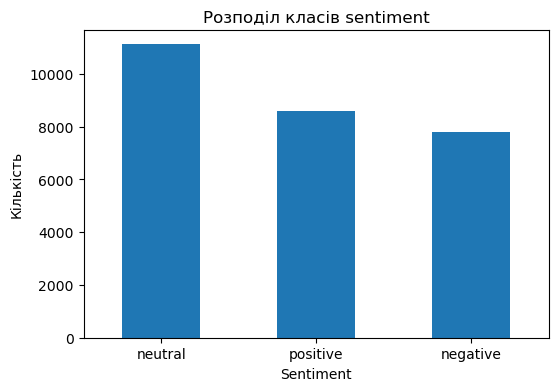

In [15]:
plt.figure(figsize=(6,4))
sentiment_counts.plot(kind='bar')
plt.title('Розподіл класів sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Кількість')
plt.xticks(rotation=0)
plt.show()

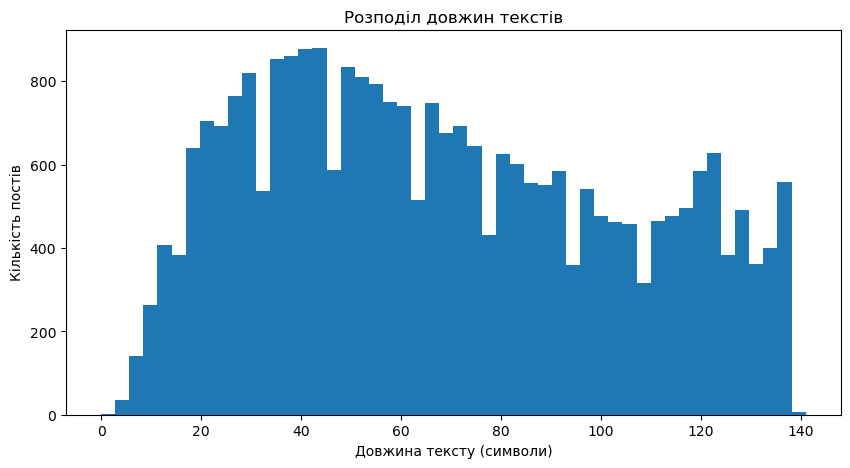

In [20]:
plt.figure(figsize=(10,5))
plt.hist(df['text_len'], bins=50)
plt.title('Розподіл довжин текстів')
plt.xlabel('Довжина тексту (символи)')
plt.ylabel('Кількість постів')
plt.show()

Середня кількість символів у пості - 68. Найбільше постів з кількістю символів у діапазоні 30-70 символів. Найменше постів із кількістю символів до 10.

### Завдання 3. Попередня обробка текстових даних та векторизація з bag of words


Наша задача тут отримати вектори методом bag of words колонки `text`, виконавши попередню обробку тексту.
Попередня обробка має включати
- видалення stopwords необхідної мови
- токенізація (розбиття текстів на фрагменти по 1 слову)
- стеммінг слів зі `SnowballStemmer`.
- самостійно задайте кількість слів в словнику для `sklearn.feature_extraction.text.CountVectorizer`. Можливо для цього доведеться виконати додатковий аналіз.

Ви також можете додати сюди додаткові методи очистки текстів, наприклад, видалення деяких символів чи груп символів, якщо в процесі роботи побачите, що хочете щось видалити.

Напишіть код аби виконати це завдання. Перед цим рекомендую детально ознайомитись з тим, що робить обʼєкт `sklearn.feature_extraction.text.CountVectorizer` за замовченням.

Це завдання можна виконати двома способами - один - максимально подібно до того, як ми це робили в лекції, другий - дещо інакше перегрупувавши етапи обробки тексту.




In [8]:
nltk.download('stopwords')
nltk.download('punkt')
english_stopwords = set(stopwords.words('english'))
stemmer = SnowballStemmer(language='english')

[nltk_data] Downloading package stopwords to /Users/oleh/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /Users/oleh/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [9]:
def clean_text(text):
    text = str(text).lower()

    # прибираємо посилання
    text = re.sub(r'http\S+|www\S+', ' ', text)

    # прибираємо згадки типу @username
    text = re.sub(r'@\w+', ' ', text)

    # прибираємо хештеги, але залишаємо саме слово
    text = re.sub(r'#', '', text)

    # залишаємо тільки літери і пробіли
    text = re.sub(r'[^a-z\s]', ' ', text)

    # прибираємо зайві пробіли
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [10]:
def tokenize(text):
    text = clean_text(text)

    tokens = word_tokenize(text)

    tokens = [
        stemmer.stem(word)
        for word in tokens
        if word not in english_stopwords and len(word) > 1
    ]

    return tokens

In [11]:
all_tokens = []

for text in df['text'].fillna(''):
    all_tokens.extend(tokenize(text))

vocab_size = len(set(all_tokens))
vocab_size

18528

In [12]:
vectorizer = CountVectorizer(
    tokenizer=tokenize,
    lowercase=False,
    max_features=5000
)

X = vectorizer.fit_transform(df['text'].fillna(''))

/Users/oleh/miniconda3/envs/ml-2/lib/python3.13/site-packages/sklearn/feature_extraction/text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [13]:
vectorizer.get_feature_names_out()[:50]

array(['aaaah', 'aaah', 'aaahhh', 'aah', 'aaron', 'ab', 'abandon', 'abbi',
       'abc', 'abil', 'abit', 'abl', 'absolut', 'abt', 'abus', 'ac',
       'academ', 'academi', 'accept', 'access', 'accid', 'accident',
       'accomplish', 'accord', 'account', 'acct', 'ace', 'ach', 'achiev',
       'acid', 'ack', 'acquir', 'across', 'act', 'action', 'activ',
       'actor', 'actress', 'actual', 'ad', 'ada', 'adam', 'adapt', 'add',
       'addict', 'addit', 'address', 'adjust', 'admir', 'admit'],
      dtype=object)

### Завдання 4. Побудова класифікатора

- Розділіть індекси даних на навчальний та тестовий набори в обраному співвівдношенні. Використовуючи отримані індекси сфомуйте набори для тренування класифікатора `X_train_bow, X_test_bow, y_train, y_test`.
- Навчіть класифікатор (наприклад, Logistic Regression, Decision Tree або один з алгоритмів бустингу) на даних, векторизованих методом bag-of-words. Спробуйте кілька моделей і оберіть найбільш точну :)
- Виведіть інформацію, яка дає можливість оцінити якість класифікації.
- Оцініть якість фінальної класифікації: вона хороша чи не дуже?



In [23]:
X_train_bow, X_test_bow, y_train, y_test = train_test_split(X, df['sentiment'].fillna(''),
                                                                        test_size=0.3, random_state=42)

In [16]:
MAX_ITER = 1000

In [17]:
model = LogisticRegression(max_iter=MAX_ITER, solver='sag')

In [18]:
%%time
model.fit(X_train_bow, y_train)

CPU times: user 192 ms, sys: 3.56 ms, total: 196 ms
Wall time: 212 ms


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [33]:
train_preds = model.predict(X_train_bow)
test_preds = model.predict(X_test_bow)

print("Train accuracy:", accuracy_score(y_train, train_preds))
print("Test accuracy:", accuracy_score(y_test, test_preds))

print("Train f1 score:", f1_score(y_train, train_preds, average='weighted'))
print("Test f1 score:", f1_score(y_test, test_preds, average='weighted'))

Train accuracy: 0.8247036805988771
Test accuracy: 0.6889023650697392
Train f1 score: 0.82473240776493
Test f1 score: 0.6890726531113637


In [34]:
from sklearn.metrics import classification_report

print(classification_report(y_test, test_preds))

              precision    recall  f1-score   support

    negative       0.71      0.62      0.66      2338
     neutral       0.64      0.72      0.68      3371
    positive       0.75      0.71      0.73      2536

    accuracy                           0.69      8245
   macro avg       0.70      0.68      0.69      8245
weighted avg       0.69      0.69      0.69      8245



In [36]:
knn = KNeighborsClassifier(n_neighbors=11)
knn.fit(X_train_bow, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",11
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [43]:
y_train_knn_preds = knn.predict(X_train_bow)
y_test_knn_preds = knn.predict(X_test_bow)

print("Accuracy Train KNN:", accuracy_score(y_train, y_train_knn_preds))
print("Accuracy Test KNN:", accuracy_score(y_test, y_test_knn_preds))

print("Train f1 score:", f1_score(y_train, y_train_knn_preds, average='weighted'))
print("Test f1 score:", f1_score(y_test, y_test_knn_preds, average='weighted'))

Accuracy Train KNN: 0.5885319193179456
Accuracy Test KNN: 0.5604608853850819
Train f1 score: 0.5648966734063409
Test f1 score: 0.530085316963668


In [46]:
d_tree = DecisionTreeClassifier(random_state=42, max_depth=6, max_leaf_nodes=18)
d_tree.fit(X_train_bow, y_train)

d_tree_train_preds = d_tree.predict(X_train_bow)
d_tree_test_preds = d_tree.predict(X_test_bow)

print("Train DT accuracy:", accuracy_score(y_train, d_tree_train_preds))
print("Test DT accuracy:", accuracy_score(y_test, d_tree_test_preds))

print("Train DT f1 score:", f1_score(y_train, d_tree_train_preds, average='weighted'))
print("Test DT f1 score:", f1_score(y_test, d_tree_test_preds, average='weighted'))

Train DT accuracy: 0.536234144312747
Test DT accuracy: 0.534020618556701
Train DT f1 score: 0.4832156277277282
Test DT f1 score: 0.4769475724556915


Найкращий результат показала модель LogisticRegression. На тренувальній вибірці accuracy ~ 0.82 та f1-score ~ 0.82, тоді як на тестовій вибірці accuracy ~ 0.69 та f1-score ~ 0.69. Це свідчить про певний оверфітінг моделі, проте модель все одно демонструє прийнятну здатність до узагальнення.

### Завдання 5. Аналіз впливовості слів в отриманого класифікатора

- Для обраної вами моделі проведіть аналіз важливості слів (ознак): які слова (токени) найбільше впливають для визначення сентименту? Чи це логічно на ваш погляд, що саме ці символи впливають найбільше/найменще?


In [47]:
feature_importance = pd.Series(model.coef_[0], index=vectorizer.get_feature_names_out(), name='imp').sort_values(ascending=False)
feature_importance

sad        2.685556
suck       2.457727
hate       2.322212
bore       2.219119
exhaust    2.172851
             ...   
cute      -1.831955
thank     -1.967900
love      -2.030103
glad      -2.339956
awesom    -2.343593
Name: imp, Length: 5000, dtype: float64

In [48]:
feature_names = vectorizer.get_feature_names_out()

for class_label, coef in zip(model.classes_, model.coef_):

    coef_df = pd.DataFrame({
        'feature': feature_names,
        'coef': coef
    })

    coef_df = coef_df.sort_values(by='coef', ascending=False)

    print(f'\n===== TOP words for class: {class_label} =====')
    print(coef_df.head(15))

    print(f'\n===== MOST negative words for class: {class_label} =====')
    print(coef_df.tail(15))


===== TOP words for class: negative =====
         feature      coef
3695         sad  2.685556
4213        suck  2.457727
1969        hate  2.322212
484         bore  2.219119
1434     exhaust  2.172851
4020       sorri  2.143275
4898       worst  2.066476
2793        miss  2.015192
1465        fail  2.004541
2158        hurt  2.003319
1192  disappoint  1.949023
4417        tire  1.947097
3348        poor  1.915111
4915         wtf  1.870394
1141     depress  1.866610

===== MOST negative words for class: negative =====
        feature      coef
2957       nice -1.410571
1857      great -1.459295
1375      enjoy -1.462897
1816  goodnight -1.524543
361      beauti -1.623362
3952      smile -1.645801
4791     welcom -1.679267
137        amaz -1.751659
917     congrat -1.796235
1431      excit -1.798978
1048       cute -1.831955
4354      thank -1.967900
2597       love -2.030103
1776       glad -2.339956
270      awesom -2.343593

===== TOP words for class: neutral =====
       feature

Аналіз коефіцієнтів Logistic Regression показав, що модель навчилась коректно визначати емоційне забарвлення текстів.
Для класу positive найбільші позитивні коефіцієнти мають слова:

* awesome
* thank
* cute
* love
* great

тобто слова з позитивною емоційною тональністю.

Для класу negative найбільший вплив мають:

* sad
* suck
* hate
* bore
* fail

що також відповідає негативному sentiment.

Це свідчить про те, що модель успішно навчилась виявляти емоційно забарвлені слова та використовувати їх для класифікації текстів.

### Завдання 6. Векторизація текстів з допомогою TF-IDF. Тренування класифікатора, аналіз точності і впливовості слів.

- Проведіть векторизацію текстів з векторизатором TfidfVectorizer. Реалізуйте векторизацію так, аби препроцесинг включав всі ті самі кроки, що і в випадку використання векторизації Bag of Words.

- Натренуйте той самий класифікатор на TF-IDF векторах, виконавши розбивку набору даних на train, test так, аби в трейні були всі ті самі записи, що і були в попередньому завданні (це важливо для порівняння результатів).

- Проаналізуйте якість класифікації вивівши потрібні для цього метрики. Чи стала якість класифікації кращою?

- Які токени найбільше впливають на результат при тренуваннні класифікатора з TF-IDF векторами? Порівняйте з найважливішими токенами при Bag of Words векторизації. Яку векторизацію ви б обрали для фінальної імплементації рішення? Обґрунтуйте свій вибір.



In [50]:
# Створюємо об'єкт для обчислення TF-IDF
vectorizer = TfidfVectorizer(tokenizer=tokenize, lowercase=False, max_features=5000)

# Обчислюємо TF-IDF для наших документів
tfidf_matrix = vectorizer.fit_transform(df['text'].fillna(''))

# Виводимо результати у вигляді таблиці
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=vectorizer.get_feature_names_out()).round(2)
tfidf_df

/Users/oleh/miniconda3/envs/ml-2/lib/python3.13/site-packages/sklearn/feature_extraction/text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


,aaaah,aaah,aaahhh,aah,aaron,ab,abandon,abbi,abc,abil,...,ze,zealand,zelda,zero,zoe,zombi,zone,zoo,zulu,zzzz
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27476,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
27477,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
27478,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
27479,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [51]:
X_train_tfidf, X_test_tfidf, y_train_tfidf, y_test_tfidf = train_test_split(
    tfidf_matrix,
    df['sentiment'].fillna(''),
    test_size=0.3,
    random_state=42
)

In [52]:
MAX_ITER = 1000

tfidf_model = LogisticRegression(
    max_iter=MAX_ITER,
    solver='sag',
    random_state=42
)

tfidf_model.fit(X_train_tfidf, y_train_tfidf)

tfidf_train_preds = tfidf_model.predict(X_train_tfidf)
tfidf_test_preds = tfidf_model.predict(X_test_tfidf)

In [53]:
print("Train TF-IDF accuracy:", accuracy_score(y_train_tfidf, tfidf_train_preds))
print("Test TF-IDF accuracy:", accuracy_score(y_test_tfidf, tfidf_test_preds))

print("Train TF-IDF f1 score:", f1_score(y_train_tfidf, tfidf_train_preds, average='weighted'))
print("Test TF-IDF f1 score:", f1_score(y_test_tfidf, tfidf_test_preds, average='weighted'))

print(classification_report(y_test_tfidf, tfidf_test_preds))

Train TF-IDF accuracy: 0.7817633603659805
Test TF-IDF accuracy: 0.6941176470588235
Train TF-IDF f1 score: 0.7817623732174893
Test TF-IDF f1 score: 0.6937170819694384
              precision    recall  f1-score   support

    negative       0.74      0.59      0.65      2338
     neutral       0.63      0.76      0.69      3371
    positive       0.77      0.70      0.73      2536

    accuracy                           0.69      8245
   macro avg       0.71      0.68      0.69      8245
weighted avg       0.70      0.69      0.69      8245



In [54]:
comparison = pd.DataFrame({
    'Vectorizer': ['Bag of Words', 'TF-IDF'],
    'Train Accuracy': [
        accuracy_score(y_train, train_preds),
        accuracy_score(y_train_tfidf, tfidf_train_preds)
    ],
    'Test Accuracy': [
        accuracy_score(y_test, test_preds),
        accuracy_score(y_test_tfidf, tfidf_test_preds)
    ],
    'Train F1 weighted': [
        f1_score(y_train, train_preds, average='weighted'),
        f1_score(y_train_tfidf, tfidf_train_preds, average='weighted')
    ],
    'Test F1 weighted': [
        f1_score(y_test, test_preds, average='weighted'),
        f1_score(y_test_tfidf, tfidf_test_preds, average='weighted')
    ]
})

comparison

,Vectorizer,Train Accuracy,Test Accuracy,Train F1 weighted,Test F1 weighted
0,Bag of Words,0.824704,0.688902,0.824732,0.689073
1,TF-IDF,0.781763,0.694118,0.781762,0.693717


Спостерігаємо що accuracy TF-IDF на тренувальному наборі дещо погіршилась (0.78), так само як і F1-score (0.78). Проте на тестувальному наборі помітно деякі покращення показників (accuracy - 0.694, F1 - 0.693).

In [56]:
tfidf_feature_names = vectorizer.get_feature_names_out()

for class_label, coef in zip(tfidf_model.classes_, tfidf_model.coef_):

    coef_df = pd.DataFrame({
        'feature': tfidf_feature_names,
        'coef': coef
    })

    coef_df = coef_df.sort_values(by='coef', ascending=False)

    print(f'\n===== TOP TF-IDF words for class: {class_label} =====')
    print(coef_df.head(15))

    print(f'\n===== MOST negative TF-IDF words for class: {class_label} =====')
    print(coef_df.tail(15))


===== TOP TF-IDF words for class: negative =====
      feature      coef
3695      sad  5.206051
2793     miss  4.683592
4213     suck  4.306392
1969     hate  4.214640
4020    sorri  4.063579
484      bore  3.572943
1465     fail  3.434160
2158     hurt  3.402994
3348     poor  3.276356
4417     tire  3.189055
3864     sick  3.067760
299       bad  3.040903
4202   stupid  3.037856
4898    worst  2.624822
1985  headach  2.525003

===== MOST negative TF-IDF words for class: negative =====
     feature      coef
1950   happi -1.916823
1811    good -1.943739
4791  welcom -1.946875
1375   enjoy -2.021982
2957    nice -2.171157
1048    cute -2.174021
137     amaz -2.269052
397   better -2.333931
1431   excit -2.401732
1857   great -2.573478
2102    hope -2.822096
1776    glad -2.825552
270   awesom -3.185265
4354   thank -3.835944
2597    love -4.623721

===== TOP TF-IDF words for class: neutral =====
       feature      coef
1218        dm  1.247222
3778      sent  1.134174
4770   watchin

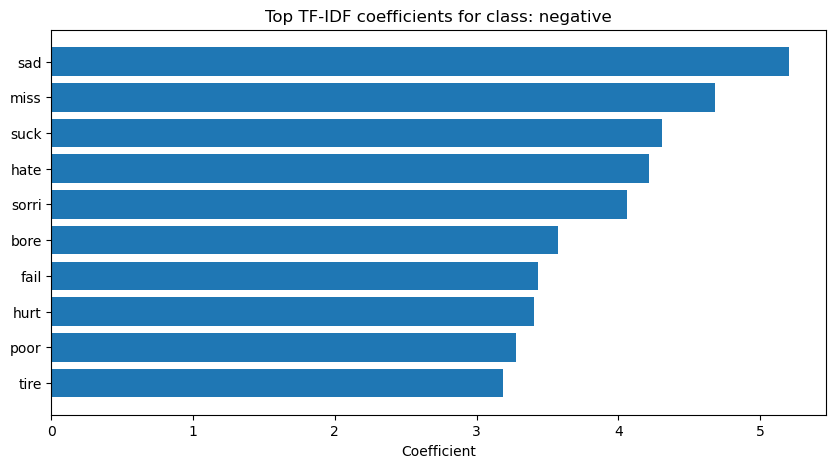

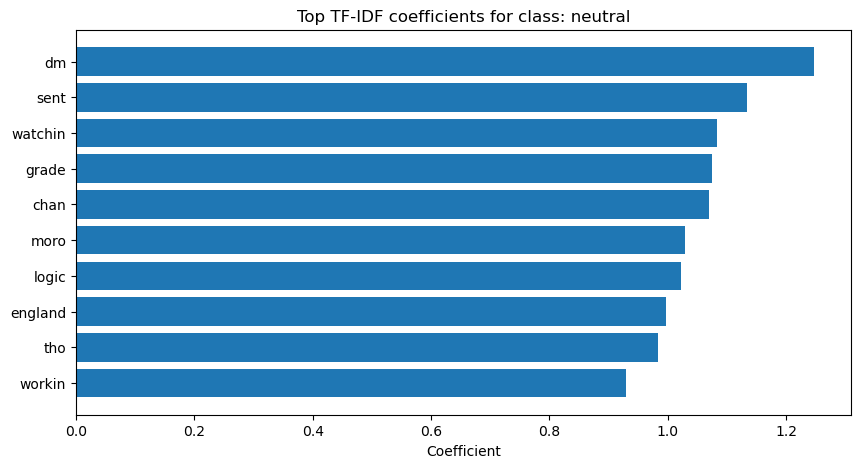

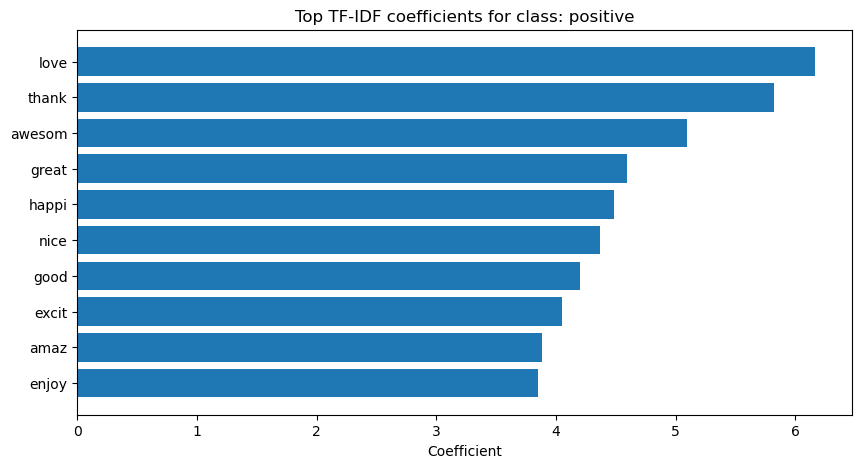

In [57]:
for class_index, class_label in enumerate(tfidf_model.classes_):

    coef_df = pd.DataFrame({
        'feature': tfidf_feature_names,
        'coef': tfidf_model.coef_[class_index]
    })

    top_positive = coef_df.sort_values(by='coef', ascending=False).head(10)

    plt.figure(figsize=(10, 5))

    plt.barh(
        top_positive['feature'][::-1],
        top_positive['coef'][::-1]
    )

    plt.title(f'Top TF-IDF coefficients for class: {class_label}')
    plt.xlabel('Coefficient')

    plt.show()

Можемо спостерігати що багато однакових токенів при Bag of Words і TF-IDF векторизації. Negative: sad, suck, hate, miss, bore. Positive: awesome, thank, love, excite, happi. Neutral: chan, moro, grade. Це означає що обидва методи векторизації виявляють схожі за емоціями слова.
Tf-IDF зменшує вплив дуже частих слів і краще виділяє більш специфічні токени, тому краще використати цей метод для фінальної імплементації.

### Завдання 7. Аналіз помилок класифікації з векторизацією TF-IDF.

- Проаналізуйте, на яких екземплярах помиляється класифікатор при векторизації TF-IDF.
- На основі аналізу запропонуйте 3 шляхи поліпшення якості класифікації.

In [59]:
test_probs = tfidf_model.predict_proba(X_test_tfidf)

errors_df = pd.DataFrame({
    'text': df.loc[y_test_tfidf.index, 'text'],
    'true_label': y_test_tfidf,
    'predicted_label': tfidf_test_preds,
    'max_probability': test_probs.max(axis=1)
})

errors_df = errors_df[
    errors_df['true_label'] != errors_df['predicted_label']
]

errors_df = errors_df.sort_values(
    by='max_probability',
    ascending=False
)

errors_df.head(20)

,text,true_label,predicted_label,max_probability
24355,Not a happy camper not having a good day at a...,negative,positive,0.998671
16424,why are you sad?!,neutral,negative,0.996257
15347,i am not happy at all,negative,positive,0.993786
14919,"made it into leadership, buttt i`m still not h...",negative,positive,0.989333
22966,missing ontario..,neutral,negative,0.988743
26783,"c is nice, but I wouldn`t call it fun",neutral,positive,0.985427
10906,nice have fun....Although you cant not have f...,neutral,positive,0.981443
9485,omg i forgot about that! you lucky thing! hop...,neutral,positive,0.970305
11892,i ditched school ( i hate it ) and im taking a...,positive,negative,0.961694
6173,I wasn`t sore yesterday. But i`m definitely fe...,positive,negative,0.961668


Класифікатор часто помиляється якщо текст із сарказмом або іронією, не розуміє частки 'not', у тексті змішані емоції. Шляхи покращення:
- покращити препроцесинг (обєднати not із словом not_good, обробка емодзі, збереження знаків оклику)
- враховувати словосполучення, а не тільки окремі слова (n-grams)
- використати сучасні embedding-modeks (Word2Vec, BERT)

І на фінал кернел для натхнення і ознайомлення з рішенням оригінальної задачі. Багато цікавих візуалізацій і аналізу є тут, а також тут розвʼязується саме проблема named entitty recognition і можна ознайомитись як це робиться - вона дещо складніша по своїй суті ніж класифікація, подумайте, чому:

https://www.kaggle.com/code/tanulsingh077/twitter-sentiment-extaction-analysis-eda-and-model